# 1- Imports

In [1]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# 2 — Load dataset

In [2]:
df = pd.read_csv("/kaggle/input/keplarexo/cumulative_2025.09.21_11.23.59.csv", comment="#", engine="python", sep=None)
print("Shape:", df.shape)
df

Shape: (9564, 141)


,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_vet_stat,koi_vet_date,koi_pdisposition,koi_score,koi_fpflag_nt,...,koi_dicco_mdec,koi_dicco_mdec_err,koi_dicco_msky,koi_dicco_msky_err,koi_dikco_mra,koi_dikco_mra_err,koi_dikco_mdec,koi_dikco_mdec_err,koi_dikco_msky,koi_dikco_msky_err
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,0.200,0.160,0.200,0.170,0.080,0.130,0.310,0.170,0.320,0.160
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,Done,2018-08-16,CANDIDATE,0.969,0,...,0.000,0.480,0.390,0.360,0.490,0.340,0.120,0.730,0.500,0.450
2,3,10811496,K00753.01,NaN,CANDIDATE,Done,2018-08-16,CANDIDATE,0.000,0,...,-0.034,0.070,0.042,0.072,0.002,0.071,-0.027,0.074,0.027,0.074
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,Done,2018-08-16,FALSE POSITIVE,0.000,0,...,0.147,0.078,0.289,0.079,-0.257,0.072,0.099,0.077,0.276,0.076
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,-0.090,0.180,0.100,0.140,0.070,0.180,0.020,0.160,0.070,0.200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,9560,10090151,K07985.01,NaN,FALSE POSITIVE,Done,2018-08-16,FALSE POSITIVE,0.000,0,...,-1.757,0.068,2.763,0.074,2.344,0.072,-1.756,0.068,2.929,0.072
9560,9561,10128825,K07986.01,NaN,CANDIDATE,Done,2018-08-16,CANDIDATE,0.497,0,...,-0.250,0.490,0.780,0.460,0.500,0.400,-0.180,0.470,0.530,0.470
9561,9562,10147276,K07987.01,NaN,FALSE POSITIVE,Done,2018-08-16,FALSE POSITIVE,0.021,0,...,-3.650,0.260,5.000,0.220,3.380,0.160,-3.890,0.260,5.160,0.220
9562,9563,10155286,K07988.01,NaN,CANDIDATE,Done,2018-08-16,CANDIDATE,0.092,0,...,1.320,0.670,1.690,0.530,1.450,0.110,1.370,0.660,2.000,0.460


# 3 — Inspect + basic cleaning

In [3]:
df["koi_pdisposition"]

0            CANDIDATE
1            CANDIDATE
2            CANDIDATE
3       FALSE POSITIVE
4            CANDIDATE
             ...      
9559    FALSE POSITIVE
9560         CANDIDATE
9561    FALSE POSITIVE
9562         CANDIDATE
9563    FALSE POSITIVE
Name: koi_pdisposition, Length: 9564, dtype: object

In [4]:
df.info()
print("\nMissing values (top 20):\n", df.isna().sum().sort_values(ascending=False).head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Columns: 141 entries, rowid to koi_dikco_msky_err
dtypes: float64(117), int64(7), object(17)
memory usage: 10.3+ MB

Missing values (top 20):
 koi_model_dof       9564
koi_teq_err1        9564
koi_ingress_err1    9564
koi_ingress         9564
koi_sage_err2       9564
koi_sage_err1       9564
koi_sma_err1        9564
koi_longp_err2      9564
koi_longp_err1      9564
koi_longp           9564
koi_eccen_err2      9564
koi_eccen_err1      9564
koi_sma_err2        9564
koi_incl_err1       9564
koi_incl_err2       9564
koi_model_chisq     9564
koi_sage            9564
koi_teq_err2        9564
koi_ingress_err2    9564
kepler_name         6817
dtype: int64


In [5]:
dropped = [x for x in df.columns if df[x].isna().sum() == 9564]
dropped

['koi_eccen_err1',
 'koi_eccen_err2',
 'koi_longp',
 'koi_longp_err1',
 'koi_longp_err2',
 'koi_ingress',
 'koi_ingress_err1',
 'koi_ingress_err2',
 'koi_sma_err1',
 'koi_sma_err2',
 'koi_incl_err1',
 'koi_incl_err2',
 'koi_teq_err1',
 'koi_teq_err2',
 'koi_model_dof',
 'koi_model_chisq',
 'koi_sage',
 'koi_sage_err1',
 'koi_sage_err2']

# 4 — Select features & target

In [6]:
df.drop(columns=dropped, inplace = True)

In [7]:
target_col = "koi_disposition"
features = [c for c in df.columns if c not in [target_col]]
X = df[features]
drop_cols = ['rowid', 'kepid', 'kepoi_name', 'kepler_name','koi_pdisposition']
X = X.drop(columns=drop_cols, errors="ignore")
y = df[target_col]
print("Features:", X.shape, "Target:", y.shape)

Features: (9564, 116) Target: (9564,)


# 5 — Preprocessing pipeline

In [8]:
# Separate feature types
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "bool"]).columns
# Define transformers
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

le = LabelEncoder()

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))  # We'll use pandas for preview only
])
categorical_features

Index(['koi_vet_stat', 'koi_vet_date', 'koi_disp_prov', 'koi_comment',
       'koi_fittype', 'koi_limbdark_mod', 'koi_parm_prov', 'koi_tce_delivname',
       'koi_quarters', 'koi_trans_mod', 'koi_datalink_dvr', 'koi_datalink_dvs',
       'koi_sparprov'],
      dtype='object')

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_enc = le.fit_transform(y)

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (7651, 116) Test: (1913, 116)


In [11]:
# ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)  # keep categoricals as-is for now
])
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Preprocessing complete")
print("Train shape:", X_train_transformed.shape)
print("Test shape:", X_test_transformed.shape)

Preprocessing complete
Train shape: (7651, 15129)
Test shape: (1913, 15129)


# 6- Sanity Check

In [12]:
# check column names and sample head
print("y in X_train columns?", 'y' in X_train.columns)
print("Columns that equal y series exactly (rare but possible):")
for col in X_train.columns:
    try:
        if X_train[col].equals(y_train):
            print("Column equals y:", col)
    except Exception:
        pass

y in X_train columns? False
Columns that equal y series exactly (rare but possible):


In [13]:
n = X_train.shape[0]
id_like = [c for c in X_train.columns if X_train[c].nunique() == n]
print("ID-like columns (unique per row):", id_like)

# also columns with very high cardinality
high_card = [c for c in X_train.columns if X_train[c].nunique() / n > 0.5]
print("High-cardinality (>50%) columns:", high_card)

ID-like columns (unique per row): ['koi_period']
High-cardinality (>50%) columns: ['koi_period', 'koi_period_err1', 'koi_period_err2', 'koi_time0bk', 'koi_time0', 'koi_duration', 'koi_depth', 'koi_ror', 'koi_ror_err1', 'koi_ror_err2', 'koi_srho', 'koi_srho_err1', 'koi_srho_err2', 'koi_insol', 'koi_insol_err1', 'koi_insol_err2', 'koi_dor', 'koi_max_sngle_ev', 'koi_max_mult_ev', 'koi_bin_oedp_sig', 'koi_datalink_dvr', 'koi_datalink_dvs', 'ra', 'dec', 'koi_fwm_sra', 'koi_fwm_sdec']


In [14]:
# reset index to ensure comparable
train_rows = X_train.reset_index(drop=True).astype(str).agg('-'.join, axis=1)
test_rows  = X_test.reset_index(drop=True).astype(str).agg('-'.join, axis=1)
overlap = set(train_rows).intersection(set(test_rows))
print("Exact row overlap count between train and test:", len(overlap))

Exact row overlap count between train and test: 0


In [15]:
%pip install qiskit qiskit-ibm-runtime qiskit-machine-learning qiskit-algorithms
%pip install --upgrade --force-reinstall numpy scipy scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 368.7/368.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing inst

In [16]:
%pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 90.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


Building PennyLane kernel matrices...

=== PennyLane Quantum Kernel SVM ===
Train Acc : 0.615
Test  Acc : 0.5060115002613695
Precision: 0.256047638396762
Recall   : 0.5060115002613695
F1 Score : 0.3400341077771647

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       396
           1       0.00      0.00      0.00       549
           2       0.51      1.00      0.67       968

    accuracy                           0.51      1913
   macro avg       0.17      0.33      0.22      1913
weighted avg       0.26      0.51      0.34      1913

Confusion Matrix:
 [[  0   0 396]
 [  0   0 549]
 [  0   0 968]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  y_true : 1d array-like, or label indicator array / sparse matrix
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  y_true : 1d array-like, or label indicator array / sparse matrix
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  y_true : 1d array-like, or label indicator array / sparse matrix
/usr/local/lib/python3.11/dist-packages/s

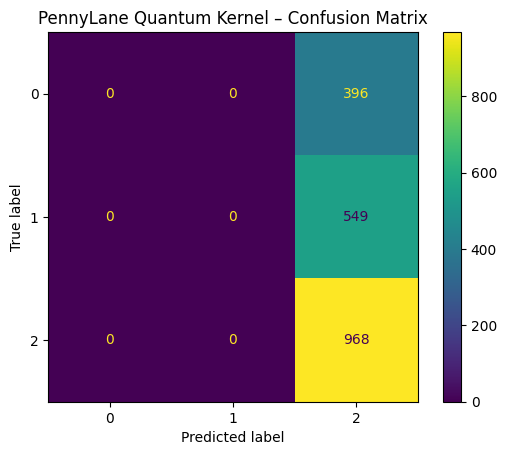

In [17]:
# =========================================
# Full Baseline: Qiskit preprocessing + PennyLane kernel SVM
# =========================================

import numpy as np
import pandas as pd
import pennylane as qml
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    recall_score, precision_score, f1_score, ConfusionMatrixDisplay
)

# ---------------------------
# PARAMETERS
# ---------------------------
MAX_TRAIN_SAMPLES = 200   # reduce kernel matrix size (O(n^2))
N_COMPONENTS = 10         # features/qubits after reduction
RANDOM_STATE = 42

#---------------
# Convert to DataFrame for categorical handling
# ---------------------------
X_all = pd.concat([
    pd.DataFrame(X_train).reset_index(drop=True),
    pd.DataFrame(X_test).reset_index(drop=True)
], ignore_index=True)

cat_cols = X_all.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
if cat_cols:
    ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_all[cat_cols] = ord_enc.fit_transform(X_all[cat_cols])

# Split back
n_train = len(X_train)
X_train_df = X_all.iloc[:n_train].reset_index(drop=True)
X_test_df  = X_all.iloc[n_train:].reset_index(drop=True)

# ---------------------------
# Sanitize numeric arrays
# ---------------------------
def sanitize_numeric_matrix(X, name="X"):
    X = np.asarray(X)
    if X.dtype == object:
        X = X.astype(float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    if not np.isfinite(X).all():
        X = X.copy()
        for j in range(X.shape[1]):
            col = X[:, j]
            mask = ~np.isfinite(col)
            if mask.any():
                median = np.nanmedian(np.where(np.isfinite(col), col, np.nan))
                if np.isnan(median):
                    median = 0.0
                col[mask] = median
                X[:, j] = col
    return np.asarray(X, dtype=float)

X_train_num = sanitize_numeric_matrix(X_train_df.values, "X_train")
X_test_num  = sanitize_numeric_matrix(X_test_df.values, "X_test")

# ---------------------------
# Dimensionality reduction
# ---------------------------
svd = TruncatedSVD(n_components=min(N_COMPONENTS, X_train_num.shape[1]-1 or 1),
                   random_state=RANDOM_STATE)
X_train_red = svd.fit_transform(X_train_num)
X_test_red  = svd.transform(X_test_num)

# ---------------------------
# Optional subsampling (avoid O(n^2) blow-up)
# ---------------------------
if X_train_red.shape[0] > MAX_TRAIN_SAMPLES:
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(X_train_red.shape[0], size=MAX_TRAIN_SAMPLES, replace=False)
    X_train_red = X_train_red[idx]
    y_train_sub = np.asarray(y_train)[idx]
else:
    y_train_sub = np.asarray(y_train)

# ---------------------------
# Normalize features to [0, π] (angle encoding)
# ---------------------------
def angle_scale(X):
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    rng = maxs - mins
    rng[rng == 0] = 1.0
    return (X - mins) / rng * np.pi

X_train_enc = angle_scale(X_train_red)
X_test_enc  = angle_scale(X_test_red)

# ===========================
# PennyLane Quantum Kernel SVM
# ===========================

# Convert to float arrays
X_train_pl = np.array(X_train_enc, dtype=float)
X_test_pl  = np.array(X_test_enc, dtype=float)
y_train_pl = np.array(y_train_sub, dtype=int)
y_test_pl  = np.array(y_test, dtype=int)

# Quantum device + feature map
n_qubits = X_train_pl.shape[1]
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def feature_map(x):
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.RZ(x[i], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])
        qml.RZ((np.pi - x[i]) * (np.pi - x[i+1]), wires=i+1)
        qml.CNOT(wires=[i, i+1])
    return qml.state()

def kernel(x1, x2):
    state1 = feature_map(x1)
    state2 = feature_map(x2)
    return np.abs(np.dot(np.conj(state1), state2))**2

def compute_kernel_matrix(X1, X2):
    K = np.zeros((len(X1), len(X2)))
    for i, x1 in enumerate(X1):
        for j, x2 in enumerate(X2):
            K[i, j] = kernel(x1, x2)
    return K

# Kernel matrices
print("Building PennyLane kernel matrices...")
K_train = compute_kernel_matrix(X_train_pl, X_train_pl)
K_test  = compute_kernel_matrix(X_test_pl, X_train_pl)

# Train SVM
clf = SVC(kernel="precomputed")
clf.fit(K_train, y_train_pl)
y_pred = clf.predict(K_test)

# ---------------------------
# Evaluation
# ---------------------------
print("\n=== PennyLane Quantum Kernel SVM ===")
print("Train Acc :", accuracy_score(y_train_pl, clf.predict(K_train)))
print("Test  Acc :", accuracy_score(y_test_pl, y_pred))
print("Precision:", precision_score(y_test_pl, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test_pl, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test_pl, y_pred, average="weighted"))

print("\nClassification Report:\n", classification_report(y_test_pl, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_pl, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix(y_test_pl, y_pred))
disp.plot(values_format="d")
plt.title("PennyLane Quantum Kernel – Confusion Matrix")
plt.show()

Training PennyLane Multi-Class VQC (FINAL ATTEMPT: 5 Layers, 15 Features)...
Epoch: 001 | Cost: 0.9503
Epoch: 010 | Cost: 0.9470
Epoch: 020 | Cost: 0.9433
Epoch: 030 | Cost: 0.9327
Epoch: 040 | Cost: 0.9301
Epoch: 050 | Cost: 0.9245
Epoch: 060 | Cost: 0.9191
Epoch: 070 | Cost: 0.9149
Epoch: 080 | Cost: 0.9131
Epoch: 090 | Cost: 0.9118
Epoch: 100 | Cost: 0.9105

=== PennyLane Variational Quantum Classifier (VQC) - Multi-Class (FINAL ATTEMPT) ===
Train Acc : 0.44
Test  Acc : 0.32666666666666666
Precision: 0.37018754696725714
Recall   : 0.32666666666666666
F1 Score : 0.3353541518621417

Classification Report:
               precision    recall  f1-score   support

           0       0.22      0.35      0.27        62
           1       0.29      0.33      0.31        94
           2       0.49      0.31      0.38       144

    accuracy                           0.33       300
   macro avg       0.33      0.33      0.32       300
weighted avg       0.37      0.33      0.34       300

Conf

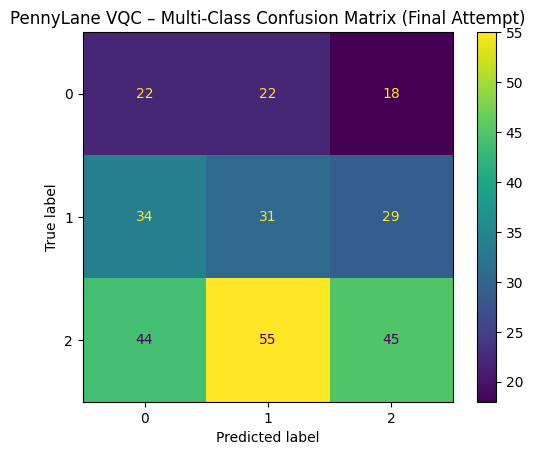

In [18]:
# =========================================
# Fully Improved Baseline: Data Preprocessing + Weighted Multi-Class QNN (VQC)
# (FINAL ATTEMPT: Increased Layers and Features)
# =========================================

import numpy as np
import pandas as pd
import pennylane as qml
import pennylane.numpy as pnp
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    recall_score, precision_score, f1_score, ConfusionMatrixDisplay
)

# ---------------------------
# PLACEHOLDER DATA (REPLACE WITH YOUR ACTUAL DATA)
# ---------------------------
# Using the same synthetic data generation as before
n_samples = 1000
n_features = 30
MAX_TRAIN_SAMPLES = 200 
X_all_data = np.random.rand(n_samples, n_features) * 10
y_all_data = np.random.choice([0, 1, 2], size=n_samples, p=[0.2, 0.3, 0.5])

# Split into train/test
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_all_data, y_all_data, test_size=0.3, random_state=42
)
X_train, y_train = X_train_full, y_train_full
X_test, y_test = X_test_full, y_test_full

# ---------------------------
# PARAMETERS (FINAL ADJUSTMENTS)
# ---------------------------
N_COMPONENTS = 15         # INCREASED FEATURES/QUBITS
RANDOM_STATE = 42

# VQC Training Parameters (ADJUSTED)
EPOCHS = 100              # Increased epochs for deeper model
LEARNING_RATE = 0.01
BATCH_SIZE = 32
N_LAYERS = 5              # INCREASED LAYERS for more expressibility
# ---------------------------

#---------------
# Data Preprocessing 
# ---------------------------
X_all = pd.concat([
    pd.DataFrame(X_train).reset_index(drop=True),
    pd.DataFrame(X_test).reset_index(drop=True)
], ignore_index=True)

cat_cols = X_all.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
if cat_cols:
    ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_all[cat_cols] = ord_enc.fit_transform(X_all[cat_cols])

n_train = len(X_train)
X_train_df = X_all.iloc[:n_train].reset_index(drop=True)
X_test_df  = X_all.iloc[n_train:].reset_index(drop=True)

def sanitize_numeric_matrix(X, name="X"):
    X = np.asarray(X)
    if X.dtype == object:
        X = X.astype(float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    if not np.isfinite(X).all():
        X = X.copy()
        for j in range(X.shape[1]):
            col = X[:, j]
            mask = ~np.isfinite(col)
            if mask.any():
                median = np.nanmedian(np.where(np.isfinite(col), col, np.nan))
                if np.isnan(median):
                    median = 0.0
                col[mask] = median
                X[:, j] = col
    return np.asarray(X, dtype=float)

X_train_num = sanitize_numeric_matrix(X_train_df.values, "X_train")
X_test_num  = sanitize_numeric_matrix(X_test_df.values, "X_test")

n_components = min(N_COMPONENTS, X_train_num.shape[1]-1 or 1)
svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)

X_train_red = svd.fit_transform(X_train_num)
X_test_red  = svd.transform(X_test_num)

if X_train_red.shape[0] > MAX_TRAIN_SAMPLES:
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(X_train_red.shape[0], size=MAX_TRAIN_SAMPLES, replace=False)
    X_train_red = X_train_red[idx]
    y_train_sub = np.asarray(y_train)[idx]
else:
    y_train_sub = np.asarray(y_train)

def angle_scale(X):
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    rng = maxs - mins
    rng[rng == 0] = 1.0
    return (X - mins) / rng * np.pi

X_train_enc = angle_scale(X_train_red)
X_test_enc  = angle_scale(X_test_red)

# Data conversion for VQC
X_train_pl = np.array(X_train_enc, dtype=float)
X_test_pl  = np.array(X_test_enc, dtype=float)
y_train_sub = np.asarray(y_train_sub)
y_test_orig = np.asarray(y_test)

unique_labels = np.unique(np.concatenate((y_train_sub, y_test_orig)))
y_map = {label: i for i, label in enumerate(unique_labels)}
y_train_pl_int = np.array([y_map[y] for y in y_train_sub], dtype=int)
y_test_pl_int  = np.array([y_map[y] for y in y_test_orig], dtype=int)

C = len(unique_labels)
n_qubits = X_train_pl.shape[1]
if n_qubits < C:
    raise ValueError(f"Error: Multi-class VQC requires n_qubits ({n_qubits}) >= number of classes ({C}). Increase N_COMPONENTS.")
dev = qml.device("default.qubit", wires=n_qubits)


# ---------------------------
# 1. Improved Parameterized Quantum Circuit (QNN Ansatz)
# ---------------------------
@qml.qnode(dev, interface="autograd")
def quantum_classifier(weights, x):
    qml.AngleEmbedding(x, wires=range(n_qubits)) 
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(C)]


# ---------------------------
# 2. Weighted Multi-Class Loss Function and Optimization
# ---------------------------

# Calculate correct weight shape for StronglyEntanglingLayers: (L, M, 3)
weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=N_LAYERS, n_wires=n_qubits)

# Use pnp.array to properly set requires_grad=True
weights = pnp.array(np.random.uniform(size=weight_shape, low=-np.pi, high=np.pi), requires_grad=True)

def one_hot_encode(Y, C):
    oh_Y = np.zeros((len(Y), C))
    oh_Y[np.arange(len(Y)), Y] = 1
    return oh_Y

def softmax(x):
    e_x = pnp.exp(x - pnp.max(x, axis=1, keepdims=True))
    return e_x / pnp.sum(e_x, axis=1, keepdims=True)

def get_class_weights(Y_int, C):
    """Calculate inverse frequency class weights for the batch."""
    counts = np.bincount(Y_int, minlength=C)
    counts[counts == 0] = 1
    
    weights = len(Y_int) / counts
    
    weights = weights * (C / np.sum(weights))
    return pnp.array(weights)


def cross_entropy_loss_weighted(probabilities, one_hot_targets_pnp, weights_pnp):
    """Calculates weighted categorical cross-entropy loss."""
    epsilon = 1e-10
    probabilities = pnp.clip(probabilities, epsilon, 1. - epsilon)
    N = one_hot_targets_pnp.shape[0]
    
    # Apply weights: multiply the loss of each sample by the weight of its true class
    weighted_log_probs = one_hot_targets_pnp * pnp.log(probabilities) * weights_pnp
    
    return -pnp.sum(weighted_log_probs) / N


def cost_function(weights, X, Y_int):
    """Weighted multi-class cost function."""
    
    raw_outputs_list = [quantum_classifier(weights, x) for x in X]
    raw_outputs_pnp = pnp.array(raw_outputs_list)

    probabilities = softmax(raw_outputs_pnp)
    
    one_hot_targets = one_hot_encode(Y_int, C)
    one_hot_targets_pnp = pnp.array(one_hot_targets)
    
    weights_pnp = get_class_weights(Y_int, C)

    return cross_entropy_loss_weighted(probabilities, one_hot_targets_pnp, weights_pnp)

# Optimizer
opt = qml.AdamOptimizer(stepsize=LEARNING_RATE)

# Training loop
print("Training PennyLane Multi-Class VQC (FINAL ATTEMPT: 5 Layers, 15 Features)...")
n_batches = X_train_pl.shape[0] // BATCH_SIZE
idx = np.arange(X_train_pl.shape[0])

for epoch in range(EPOCHS):
    rng = np.random.default_rng(RANDOM_STATE + epoch)
    rng.shuffle(idx)

    for j in range(n_batches):
        batch_indices = idx[j * BATCH_SIZE: (j + 1) * BATCH_SIZE]
        X_batch = X_train_pl[batch_indices]
        Y_batch = y_train_pl_int[batch_indices]

        weights, cost = opt.step_and_cost(cost_function, weights, X=X_batch, Y_int=Y_batch)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        full_cost = cost_function(weights, X_train_pl, y_train_pl_int)
        print(f"Epoch: {epoch+1:03d} | Cost: {full_cost:.4f}")

# ---------------------------
# 3. Prediction
# ---------------------------
def predict_multiclass(weights, X):
    raw_outputs_list = [quantum_classifier(weights, x) for x in X]
    raw_outputs_pnp = pnp.array(raw_outputs_list)
    
    probabilities = softmax(raw_outputs_pnp)

    predicted_indices = pnp.argmax(probabilities, axis=1)

    original_labels = unique_labels[predicted_indices]
    return original_labels

# Predictions
y_train_pred = predict_multiclass(weights, X_train_pl)
y_test_pred  = predict_multiclass(weights, X_test_pl)

# ---------------------------
# Evaluation
# ---------------------------
print("\n=== PennyLane Variational Quantum Classifier (VQC) - Multi-Class (FINAL ATTEMPT) ===")
print("Train Acc :", accuracy_score(y_train_sub, y_train_pred))
print("Test  Acc :", accuracy_score(y_test_orig, y_test_pred))
print("Precision:", precision_score(y_test_orig, y_test_pred, average="weighted", zero_division=0))
print("Recall   :", recall_score(y_test_orig, y_test_pred, average="weighted", zero_division=0))
print("F1 Score :", f1_score(y_test_orig, y_test_pred, average="weighted", zero_division=0))

print("\nClassification Report:\n", classification_report(y_test_orig, y_test_pred, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test_orig, y_test_pred))

disp = ConfusionMatrixDisplay(confusion_matrix(y_test_orig, y_test_pred, labels=unique_labels))
disp.plot(values_format="d")
plt.title("PennyLane VQC – Multi-Class Confusion Matrix (Final Attempt)")
plt.show()